# Random Forest Classifier for Titanic

1. Read the data

In [66]:
import pandas as pd

train_data = pd.read_csv('train.csv')

2. Treat the data

In [67]:
train_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [68]:
train_data = train_data.drop(["Name", "Cabin", "Ticket", "PassengerId"], axis=1)

In [69]:
train_data["Sex"] = train_data["Sex"].map({"male":0, "female":1})
train_data["Embarked"] = train_data["Embarked"].map({"S": 0, "C":1, "Q": 2})

In [70]:
train_data

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,0,22.0,1,0,7.2500,0.0
1,1,1,1,38.0,1,0,71.2833,1.0
2,1,3,1,26.0,0,0,7.9250,0.0
3,1,1,1,35.0,1,0,53.1000,0.0
4,0,3,0,35.0,0,0,8.0500,0.0
...,...,...,...,...,...,...,...,...
886,0,2,0,27.0,0,0,13.0000,0.0
887,1,1,1,19.0,0,0,30.0000,0.0
888,0,3,1,NaN,1,2,23.4500,0.0
889,1,1,0,26.0,0,0,30.0000,1.0


In [71]:
train_data.isna().sum()

Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Embarked      2
dtype: int64

In [72]:
train_data["Age"].mean()

np.float64(29.69911764705882)

In [73]:
train_data["Age"] = train_data["Age"].fillna(train_data["Age"].mean())

In [74]:
train_data.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,0,22.0,1,0,7.2500,0.0
1,1,1,1,38.0,1,0,71.2833,1.0
2,1,3,1,26.0,0,0,7.9250,0.0
3,1,1,1,35.0,1,0,53.1000,0.0
4,0,3,0,35.0,0,0,8.0500,0.0


In [75]:
train_data = train_data.dropna()

In [76]:
train_data.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,0,22.0,1,0,7.2500,0.0
1,1,1,1,38.0,1,0,71.2833,1.0
2,1,3,1,26.0,0,0,7.9250,0.0
3,1,1,1,35.0,1,0,53.1000,0.0
4,0,3,0,35.0,0,0,8.0500,0.0


In [77]:
train_data.isna().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

In [78]:
train_data

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,0,22.000000,1,0,7.2500,0.0
1,1,1,1,38.000000,1,0,71.2833,1.0
2,1,3,1,26.000000,0,0,7.9250,0.0
3,1,1,1,35.000000,1,0,53.1000,0.0
4,0,3,0,35.000000,0,0,8.0500,0.0
...,...,...,...,...,...,...,...,...
886,0,2,0,27.000000,0,0,13.0000,0.0
887,1,1,1,19.000000,0,0,30.0000,0.0
888,0,3,1,29.699118,1,2,23.4500,0.0
889,1,1,0,26.000000,0,0,30.0000,1.0


In [79]:
from sklearn.model_selection import train_test_split

X, y = train_data.drop(columns=["Survived"]), train_data["Survived"]

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8)

len(X_train), len(X_test), len(y_train), len(y_test)

(711, 178, 711, 178)

In [80]:
X_train[:10]

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
672,2,0,70.000000,0,0,10.5000,0.0
814,3,0,30.500000,0,0,8.0500,0.0
123,2,1,32.500000,0,0,13.0000,0.0
667,3,0,29.699118,0,0,7.7750,0.0
373,1,0,22.000000,0,0,135.6333,1.0
18,3,1,31.000000,1,0,18.0000,0.0
639,3,0,29.699118,1,0,16.1000,0.0
360,3,0,40.000000,1,4,27.9000,0.0
372,3,0,19.000000,0,0,8.0500,0.0
81,3,0,29.000000,0,0,9.5000,0.0


In [81]:
from sklearn.preprocessing import StandardScaler

scalar = StandardScaler()
scalar.fit(X_train)

X_train, X_test = scalar.transform(X_train), scalar.transform(X_test)

X_train[:10]

array([[-0.340795  , -0.75238241,  3.07063914, -0.46585761, -0.48361856,
        -0.43739366, -0.57753259],
       [ 0.8528269 , -0.75238241,  0.05345049, -0.46585761, -0.48361856,
        -0.48303995, -0.57753259],
       [-0.340795  ,  1.32911134,  0.20621954, -0.46585761, -0.48361856,
        -0.39081582, -0.57753259],
       [ 0.8528269 , -0.75238241, -0.00772452, -0.46585761, -0.48361856,
        -0.48816351, -0.57753259],
       [-1.5344169 , -0.75238241, -0.59581795, -0.46585761, -0.48361856,
         1.893982  ,  0.98974096],
       [ 0.8528269 ,  1.32911134,  0.09164275,  0.41272265, -0.48361856,
        -0.29766014, -0.57753259],
       [ 0.8528269 , -0.75238241, -0.00772452,  0.41272265, -0.48361856,
        -0.3330593 , -0.57753259],
       [ 0.8528269 , -0.75238241,  0.77910346,  0.41272265,  4.55451765,
        -0.11321188, -0.57753259],
       [ 0.8528269 , -0.75238241, -0.82497152, -0.46585761, -0.48361856,
        -0.48303995, -0.57753259],
       [ 0.8528269 , -0.7523

In [91]:
def transfrom_data(data):
    data = data.drop(["Name", "Cabin", "Ticket", "PassengerId"], axis=1)

    data["Sex"] = data["Sex"].map({"male":0, "female":1})
    data["Embarked"] = data["Embarked"].map({"S": 0, "C":1, "Q": 2})

    data["Age"] = data["Age"].fillna(data["Age"].mean())
    data["Embarked"] = data["Embarked"].fillna(data["Embarked"].mean())

    return data

def process_file(train_path: str,
                 val_path: str):
    train_data = pd.read_csv(train_path)
    val_data = pd.read_csv(val_path)

    train_data = transfrom_data(train_data)
    val_data = transfrom_data(val_data)

    X, y = train_data.drop(columns=["Survived"]), train_data["Survived"]
    X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8)

    scalar = StandardScaler()
    scalar.fit(X_train)

    X_train = pd.DataFrame(
        scalar.transform(X_train),
        columns=X_train.columns,
        index = X_train.index
    )
    X_test = pd.DataFrame(
        scalar.transform(X_test),
        columns=X_test.columns,
        index = X_test.index
    )
    X_val = pd.DataFrame(
        scalar.transform(val_data),
        columns=val_data.columns,
        index = val_data.index
    )

    return X_train, X_test, y_train, y_test, X_val    

In [92]:
X_train, X_test, y_train, y_test, X_val = process_file("train.csv", "test.csv")

X_train[:4], X_val[:4], y_test[:4]

(       Pclass       Sex       Age     SibSp     Parch      Fare  Embarked
 8    0.816934  1.359412 -0.196394 -0.470146  2.008396 -0.426325 -0.576784
 586 -0.384837 -0.735612  1.333726 -0.470146 -0.474205 -0.350778 -0.576784
 124 -1.586607 -0.735612  1.869268 -0.470146  0.767096  0.866190 -0.576784
 372  0.816934 -0.735612 -0.808443 -0.470146 -0.474205 -0.486566 -0.576784,
      Pclass       Sex       Age     SibSp     Parch      Fare  Embarked
 0  0.816934 -0.735612  0.377401 -0.470146 -0.474205 -0.490880  2.502576
 1  0.816934  1.359412  1.333726  0.397066 -0.474205 -0.507081 -0.576784
 2 -0.384837 -0.735612  2.481316 -0.470146 -0.474205 -0.454573  2.502576
 3  0.816934 -0.735612 -0.196394 -0.470146 -0.474205 -0.474599 -0.576784,
 306    1
 794    0
 858    1
 365    0
 Name: Survived, dtype: int64)

Accuracy: 0.7932960893854749
              precision    recall  f1-score   support

           0       0.80      0.85      0.82       101
           1       0.79      0.72      0.75        78

    accuracy                           0.79       179
   macro avg       0.79      0.78      0.79       179
weighted avg       0.79      0.79      0.79       179



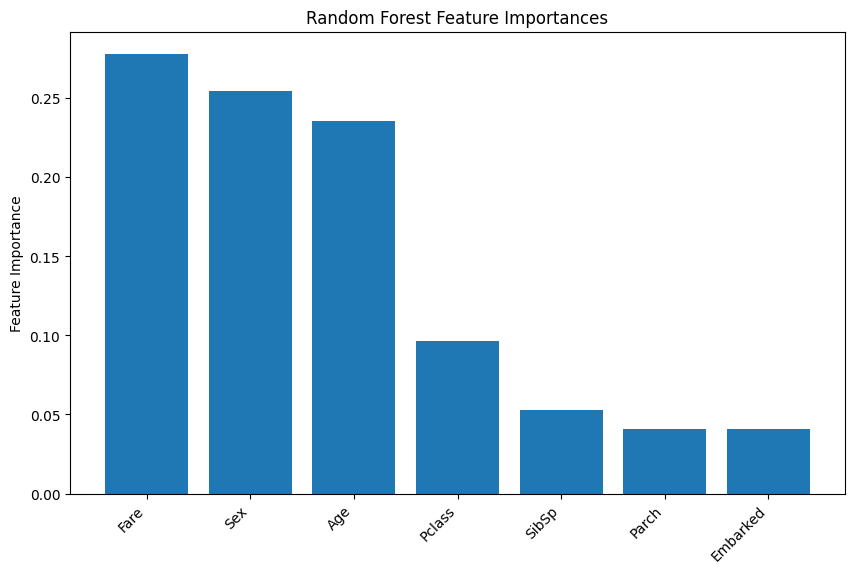

In [93]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import pandas as pd

rf_model = RandomForestClassifier()

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print(classification_report(y_test, y_pred))

feature_importances = pd.Series(rf_model.feature_importances_, index=X_train.columns)
feature_importances = feature_importances.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
plt.bar(feature_importances.index, feature_importances.values)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Feature Importance")
plt.title("Random Forest Feature Importances")
plt.show()

In [94]:
y_pred = rf_model.predict(X_val)

id = pd.read_csv("test.csv")["PassengerId"]

df = pd.DataFrame({
    "PassengerId": id,
    "Survived": y_pred
})

df

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,1
4,896,0
...,...,...
413,1305,0
414,1306,1
415,1307,0
416,1308,0


In [96]:
gender = pd.read_csv("gender_submission.csv")
gender

,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1
...,...,...
413,1305,0
414,1306,1
415,1307,0
416,1308,0


In [98]:
df.to_csv("results.csv", index=False)

In [99]:
params_grid = {
    "n_estimators": [50, 100, 200, 500, 1000],
    "max_depth": [None, 5, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 4, 10],
    "max_features": ["sqrt", "log2", 0.5]
}

In [100]:
from sklearn.model_selection import GridSearchCV

rf_model = RandomForestClassifier()

grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=params_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 5, ...], 'max_features': ['sqrt', 'log2', ...], 'min_samples_leaf': [1, 4, ...], 'min_samples_split': [2, 5], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold a

Accuracy: 0.8044692737430168
              precision    recall  f1-score   support

           0       0.76      0.95      0.85       101
           1       0.91      0.62      0.73        78

    accuracy                           0.80       179
   macro avg       0.83      0.78      0.79       179
weighted avg       0.82      0.80      0.80       179



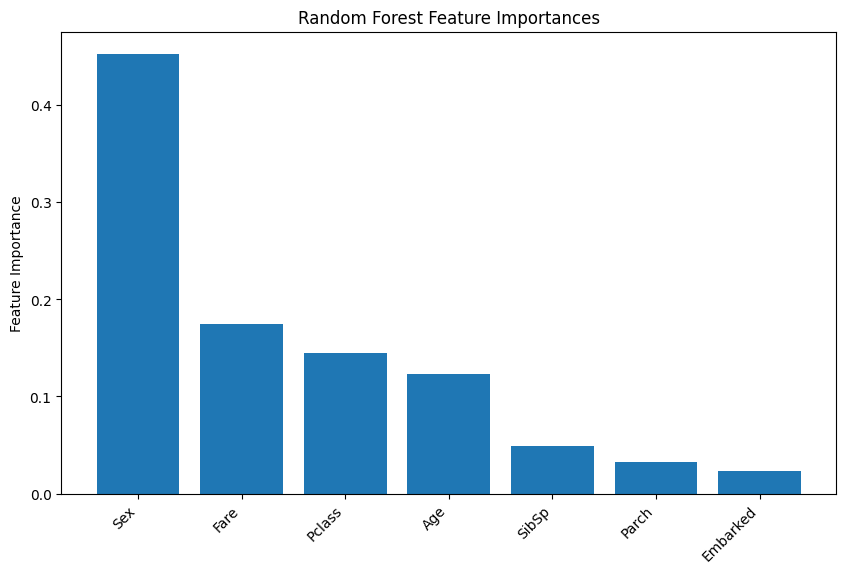

In [102]:
best_rf = grid_search.best_estimator_

y_pred = best_rf.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print(classification_report(y_test, y_pred))

feature_importances = pd.Series(best_rf.feature_importances_, index=X_train.columns)
feature_importances = feature_importances.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
plt.bar(feature_importances.index, feature_importances.values)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Feature Importance")
plt.title("Random Forest Feature Importances")
plt.show()

In [103]:
y_pred = best_rf.predict(X_val)

id = pd.read_csv("test.csv")["PassengerId"]

df = pd.DataFrame({
    "PassengerId": id,
    "Survived": y_pred
})

df.to_csv("results.csv", index=False)